In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 📥 Stage 1: Load Data

In [167]:
df=pd.read_csv(r"C:\Users\Mostafa\Desktop\python\dirty_cafe_sales.csv")

## 🔍 Stage 2: Explore Missing Values

In [168]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [169]:
df[df["Item"].isnull()==True]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
30,TXN_1736287,NaN,5,2.0,10.0,Digital Wallet,NaN,2023-06-02
61,TXN_8051289,NaN,1,3.0,3.0,NaN,In-store,2023-10-09
72,TXN_6044979,NaN,1,1.0,1.0,Cash,In-store,2023-12-08
89,TXN_4132730,NaN,5,1.0,5.0,NaN,In-store,2023-03-12
...,...,...,...,...,...,...,...,...
9820,TXN_8751702,NaN,5,NaN,15.0,Cash,NaN,2023-02-13
9855,TXN_3740505,NaN,2,1.5,3.0,NaN,NaN,2023-11-21
9876,TXN_3105633,NaN,1,2.0,2.0,NaN,In-store,2023-03-30
9885,TXN_4659954,NaN,3,4.0,12.0,Credit Card,In-store,NaN


In [170]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [171]:
df["Item"].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

## 🧹 Stage 3: Replace Invalid Values with NaN

In [172]:
for i in df.columns:
    df[i]=df[i].replace({"UNKNOWN":np.nan,"ERROR":np.nan})

 ## 🔗 Stage 4: Build Menu Lookup & Fill Missing Values

In [173]:
Menu=df[["Item","Price Per Unit"]].drop_duplicates().dropna()


In [192]:
Menu["Price Per Unit"]=Menu["Price Per Unit"].astype(float)

In [193]:
df = df.merge(Menu[["Item", "Price Per Unit"]], on="Price Per Unit", how="left", suffixes=("", "_Menu"))

df["Item"] = df["Item"].fillna(df["Item_Menu"])

df.drop(columns=["Item_Menu"], inplace=True)

In [ ]:
df = df.merge(Menu[["Item", "Price Per Unit"]], on="Item", how="left", suffixes=("", "_Menu"))

df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit_Menu"])

df.drop(columns=["Price Per Unit_Menu"], inplace=True)

In [176]:
df[df["Quantity"].isnull()==True].info()

<class 'pandas.core.frame.DataFrame'>
Index: 479 entries, 20 to 9984
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    479 non-null    object
 1   Item              420 non-null    object
 2   Quantity          0 non-null      object
 3   Price Per Unit    476 non-null    object
 4   Total Spent       459 non-null    object
 5   Payment Method    316 non-null    object
 6   Location          291 non-null    object
 7   Transaction Date  454 non-null    object
dtypes: object(8)
memory usage: 33.7+ KB


In [177]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [178]:
df["Price Per Unit"]=df["Price Per Unit"].astype(float)

In [179]:
df["Quantity"]=df["Quantity"].astype(float)

In [180]:
df["Total Spent 1"]=df["Price Per Unit"]*df["Quantity"]

In [181]:
df["Total Spent"]=df["Total Spent"].fillna(df["Total Spent 1"])

In [182]:
df.drop(columns="Total Spent 1",inplace=True)

In [183]:
df["Total Spent"]=df["Total Spent"].astype(float)

In [184]:
df["Quantity n "]=df["Total Spent"]/df["Price Per Unit"]

In [185]:
df["Quantity"]=df["Quantity"].fillna(df["Quantity n "])

In [186]:
df.drop(columns="Quantity n ",inplace=True)

In [187]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [194]:
df.isnull().sum()

Transaction ID         0
Item                  54
Quantity              33
Price Per Unit        54
Total Spent           33
Payment Method      4741
Location            5968
Transaction Date     690
dtype: int64

In [ ]:
df.drop_duplicates(inplace=True)

In [208]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
3,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
4,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
5,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
14978,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
14979,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
14980,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
14981,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


#  EDA


In [209]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
3,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
4,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
5,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
6,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
8,TXN_4433211,Cake,3.0,3.0,9.0,NaN,Takeaway,2023-10-06
9,TXN_4433211,Juice,3.0,3.0,9.0,NaN,Takeaway,2023-10-06
10,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,NaN,2023-10-28
12,TXN_4717867,Cake,5.0,3.0,15.0,NaN,Takeaway,2023-07-28


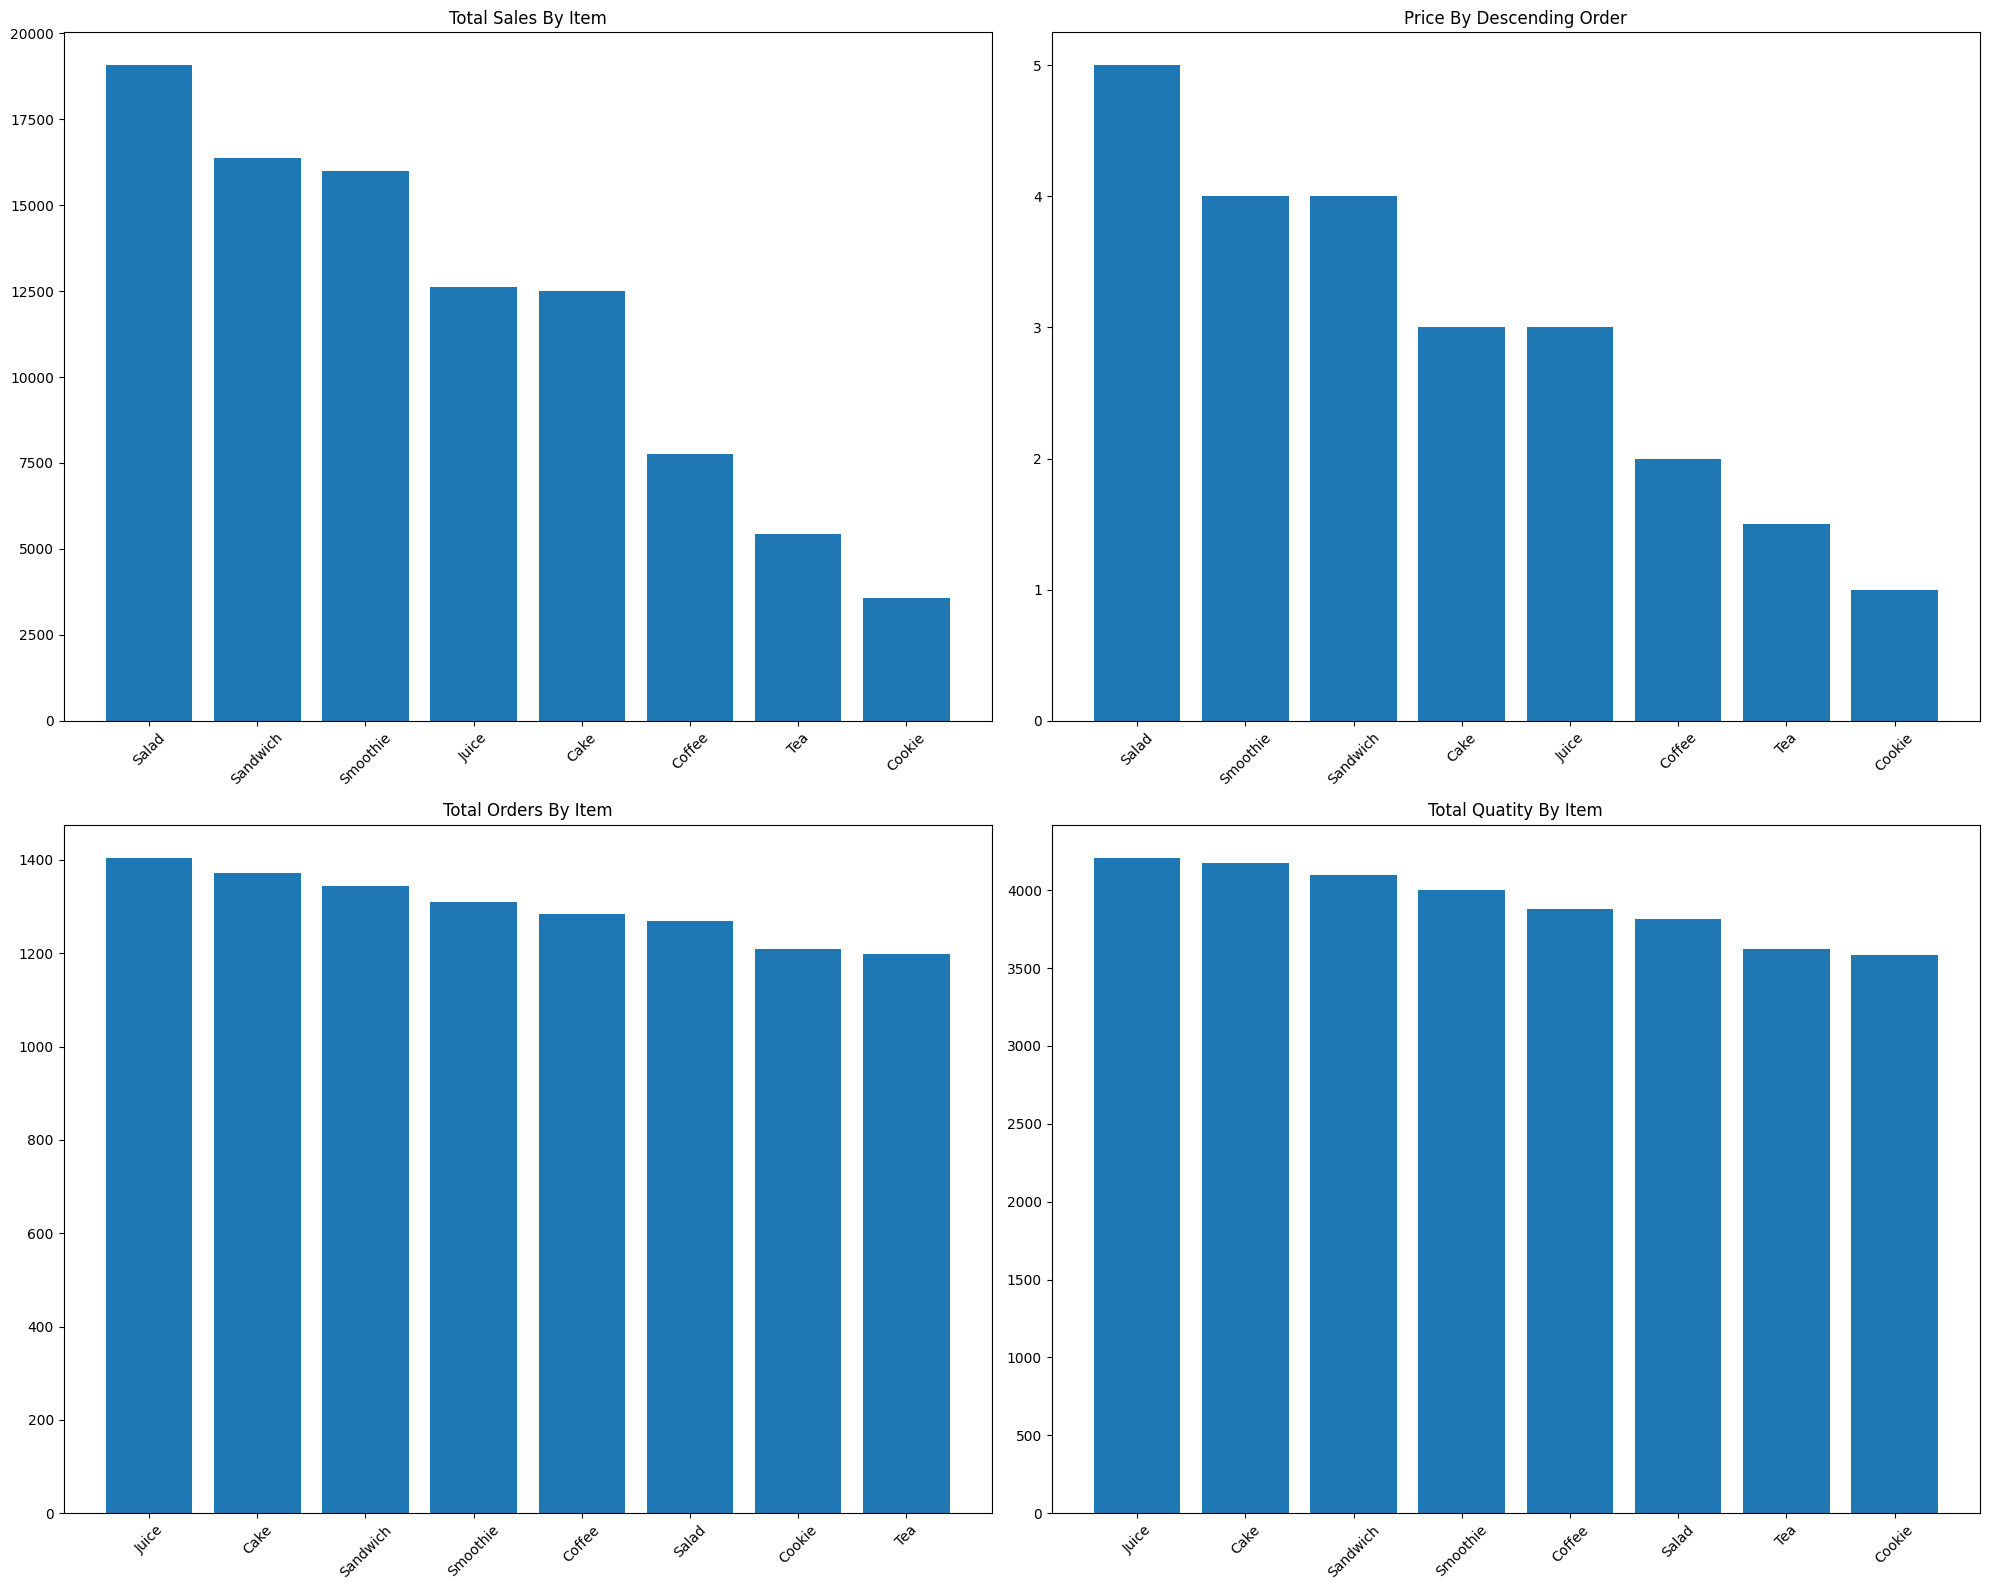

In [258]:
plt.figure(figsize=(20,16))
plt.subplot(2,2,1)
plt.bar(df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).index,df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).values)
plt.xticks(rotation=45)
plt.title("Total Sales By Item")
plt.tight_layout()
# ------------------------------------------------------------------------------
MenuSorted=Menu.sort_values(ascending=False,by=["Price Per Unit"])
plt.subplot(2,2,2)
plt.bar(MenuSorted["Item"],MenuSorted["Price Per Unit"])
plt.xticks(rotation=45)
plt.title("Price By Descending Order")
plt.tight_layout()
# ------------------------------------------------------------------------------
plt.subplot(2,2,3)
plt.bar(df.groupby("Item")["Transaction ID"].count().sort_values(ascending=False).index,df.groupby("Item")["Transaction ID"].count().sort_values(ascending=False).values)
plt.xticks(rotation=45)
plt.title("Total Orders By Item")
plt.tight_layout()
# -----------------------------------------------------------------------------
plt.subplot(2,2,4)
plt.bar(df.groupby("Item")["Quantity"].sum().sort_values(ascending=False).index,df.groupby("Item")["Quantity"].sum().sort_values(ascending=False).values)
plt.xticks(rotation=45)
plt.title("Total Quatity By Item")
plt.tight_layout()

Highest Sales by Price Not by Count Of Orders

Text(0.5, 1.0, 'Items Ordered Takeaway')

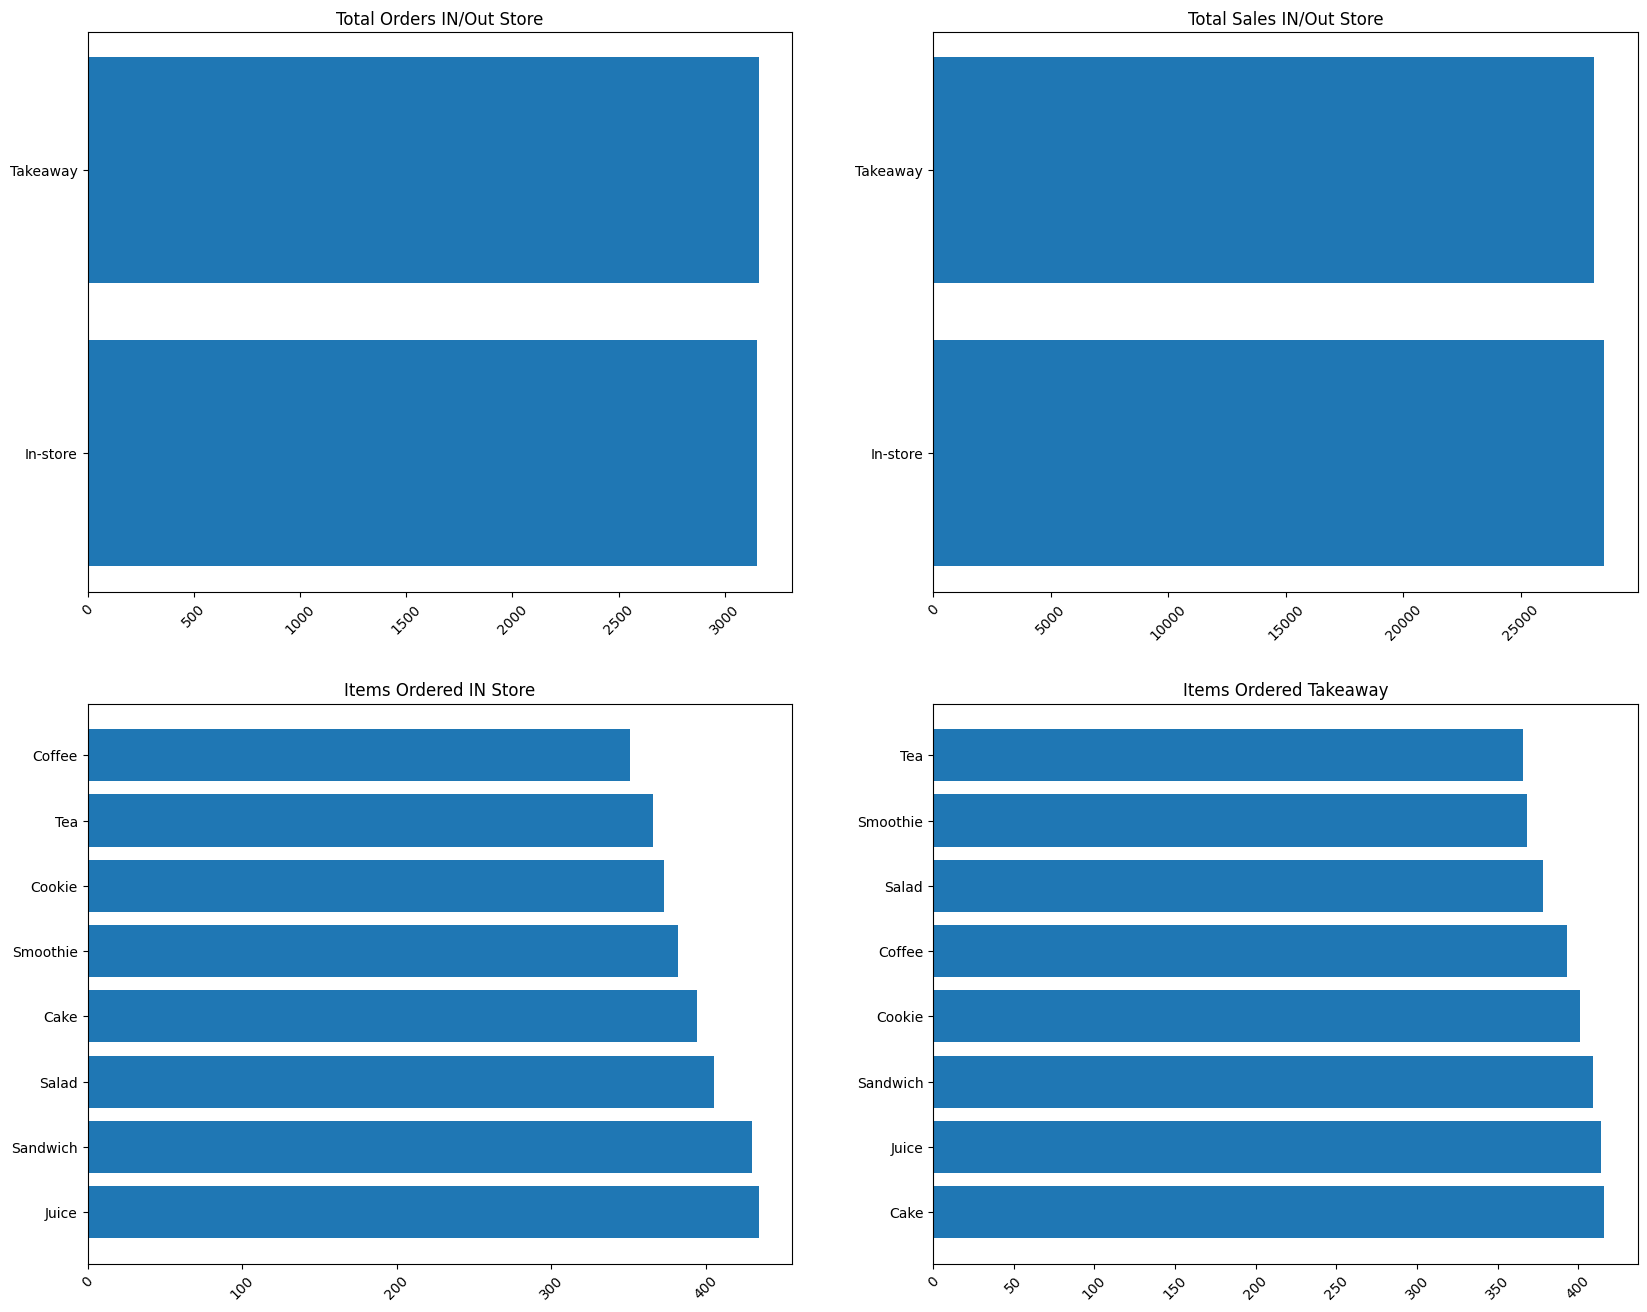

In [255]:
plt.figure(figsize=(20,16))
plt.subplot(2,2,1)
plt.barh(df.groupby("Location")["Transaction ID"].count().index,df.groupby("Location")["Transaction ID"].count().values)
plt.xticks(rotation=45)
plt.title("Total Orders IN/Out Store")
# -------------------------------------------------------------------
plt.subplot(2,2,2)
plt.barh(df.groupby("Location")["Total Spent"].sum().index,df.groupby("Location")["Total Spent"].sum().values)
plt.xticks(rotation=45)
plt.title("Total Sales IN/Out Store")
# -------------------------------------------------------------------
plt.subplot(2,2,3)
plt.barh(df[df["Location"]=="In-store"].groupby("Item")["Transaction ID"].count().sort_values(ascending=False).index,df[df["Location"]=="In-store"].groupby("Item")["Transaction ID"].count().sort_values(ascending=False).values)
plt.xticks(rotation=45)
plt.title("Items Ordered IN Store")
# -------------------------------------------------------------------
plt.subplot(2,2,4)
plt.barh(df[df["Location"]=="Takeaway"].groupby("Item")["Transaction ID"].count().sort_values(ascending=False).index,df[df["Location"]=="Takeaway"].groupby("Item")["Transaction ID"].count().sort_values(ascending=False).values)
plt.xticks(rotation=45)
plt.title("Items Ordered Takeaway")

No Differance Betweem Count Of Orders In/Out Store But The Differance in The type Orders/Item

In [256]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
3,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
4,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
5,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
6,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
8,TXN_4433211,Cake,3.0,3.0,9.0,NaN,Takeaway,2023-10-06
9,TXN_4433211,Juice,3.0,3.0,9.0,NaN,Takeaway,2023-10-06
10,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,NaN,2023-10-28
12,TXN_4717867,Cake,5.0,3.0,15.0,NaN,Takeaway,2023-07-28


Text(0.5, 1.0, 'Total Orders by Payment Mehod')

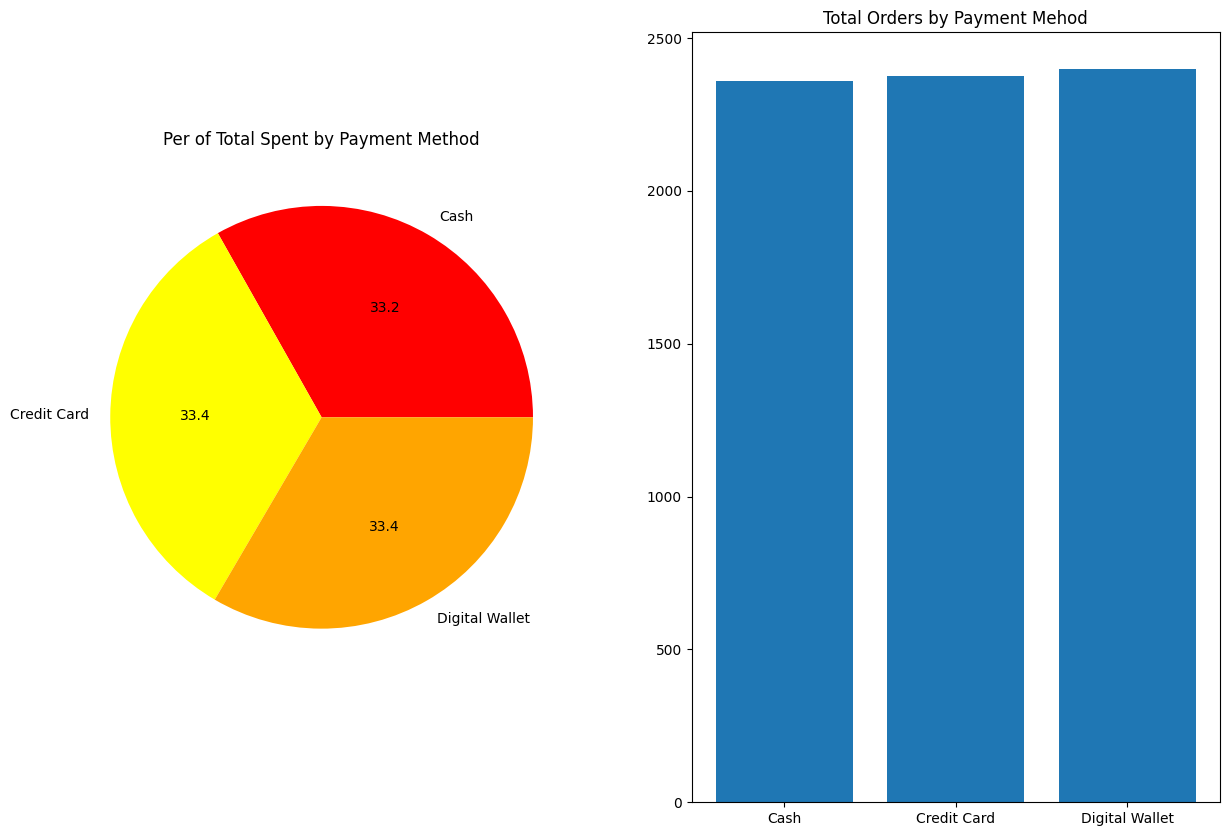

In [264]:
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.pie(df.groupby("Payment Method")["Total Spent"].sum(),labels=df.groupby("Payment Method")["Total Spent"].sum().index,autopct="%1.1f",colors=["red","yellow","orange"])
plt.title("Per of Total Spent by Payment Method")
# ----------------------------------------------------------------------
plt.subplot(1,2,2)
plt.bar(df.groupby("Payment Method")["Transaction ID"].count().index,df.groupby("Payment Method")["Transaction ID"].count().values)
plt.title("Total Orders by Payment Mehod")


In [267]:
df["Transaction Date"]=pd.to_datetime(df["Transaction Date"])

In [270]:
df["Year"]=df["Transaction Date"].dt.year
df["Month"]=df["Transaction Date"].dt.month

In [279]:
df["Year"].unique()

array([2023.,   nan])

Text(0.5, 1.0, 'Total Orders by Month')

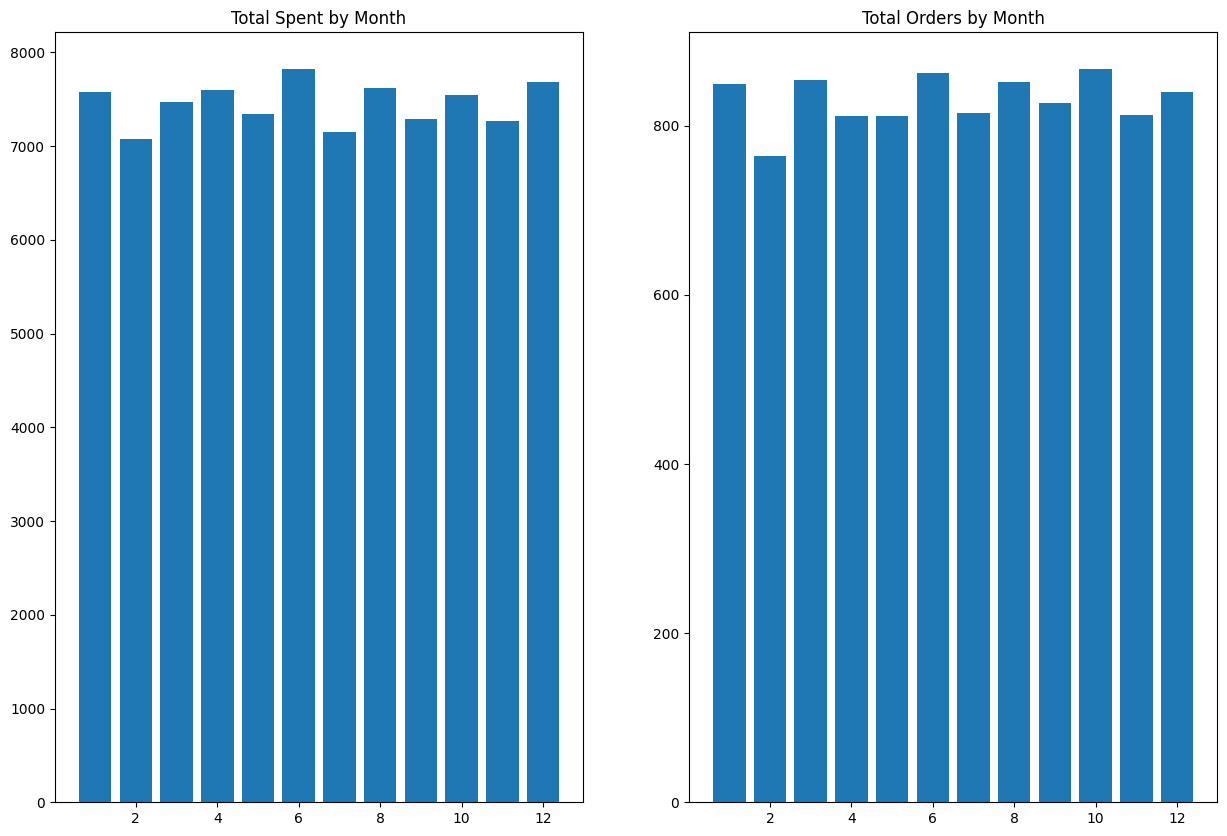

In [280]:
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.bar(df.groupby("Month")["Total Spent"].sum().sort_values(ascending=False).index,df.groupby("Month")["Total Spent"].sum().sort_values(ascending=False).values)
plt.title("Total Spent by Month")
# ------------------------------------------------------------------------
plt.subplot(1,2,2)
plt.bar(df.groupby("Month")["Transaction ID"].count().sort_values(ascending=False).index,df.groupby("Month")["Transaction ID"].count().sort_values(ascending=False).values)
plt.title("Total Orders by Month")